In [ ]:
# @title
# @no-extract
!git clone --branch uml_refactoring https://github.com/ybakhan/llm-finetuning-uml-antipatterns

!pip install unsloth
!nvidia-smi

Cloning into 'llm-based-modeling'...
remote: Enumerating objects: 5478, done.
remote: Counting objects: 100% (969/969), done.
remote: Compressing objects: 100% (336/336), done.
remote: Total 5478 (delta 716), reused 724 (delta 632), pack-reused 4509 (from 1)
Receiving objects: 100% (5478/5478), 66.49 MiB | 13.12 MiB/s, done.
Resolving deltas: 100% (3429/3429), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 5.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.2/71.2 MB 45.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 53.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 66.

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-40GB


In [ ]:
# @title
# @no-extract
!cd /content/llm-finetuning-uml-antipatterns && git pull

Already up to date.


In [ ]:
# @title
# @no-extract
yaml_path = "/content/llm-finetuning-uml-antipatterns/output/run_20260325_012118/samples.yaml"

import yaml
import pandas as pd

with open(yaml_path) as f:
    samples = yaml.safe_load(f)

df = pd.DataFrame(samples)

# Quick overview
print(f"Total samples: {len(df)}")
print(f"\nSample type distribution:\n{df['sample_type'].value_counts()}")
print(f"\nDomain count: {df['domain_id'].nunique()}")
print(f"\nSize distribution:\n{df['size'].value_counts()}")
print(f"\nAntipattern instance counts:\n{df['total_antipattern_instances'].value_counts()}")

Total samples: 388

Sample type distribution:
sample_type
antipattern    194
refactored     194
Name: count, dtype: int64

Domain count: 194

Size distribution:
size
medium    218
small     170
Name: count, dtype: int64

Antipattern instance counts:
total_antipattern_instances
0    194
1     94
3     44
2     37
4     17
5      2
Name: count, dtype: int64


In [ ]:
# @title
from datasets import load_dataset
from sklearn.model_selection import train_test_split

jsonl_path = "/content/llm-finetuning-uml-antipatterns/output/run_20260325_012118/samples.jsonl"
dataset = load_dataset("json", data_files=jsonl_path, split="train")

# Split domains
domain_ids = list(set(dataset['domain_id']))
train_domains, test_domains = train_test_split(domain_ids, test_size=0.2, random_state=42)

train_domains_set = set(train_domains)
test_domains_set = set(test_domains)

train_dataset = dataset.filter(lambda x: x['domain_id'] in train_domains_set)
test_dataset = dataset.filter(lambda x: x['domain_id'] in test_domains_set)

print(f"Train: {len(train_dataset)}")
print(f"Test:  {len(test_dataset)}")

Generating train split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/388 [00:00<?, ? examples/s]

Filter:   0%|          | 0/388 [00:00<?, ? examples/s]

Train: 310
Test:  78


In [8]:
# @title
# @no-extract
print("=== Train ===")
for i in range(len(train_dataset)):
    print(f"  {train_dataset[i]['sample_id']} → domain {train_dataset[i]['domain_id']}")

print(f"\n=== Test ===")
for i in range(len(test_dataset)):
    print(f"  {test_dataset[i]['sample_id']} → domain {test_dataset[i]['domain_id']}")

# Verify no domain leaks
train_domain_set = set(train_dataset['domain_id'])
test_domain_set = set(test_dataset['domain_id'])
overlap = train_domain_set & test_domain_set
print(f"\nTrain domains: {len(train_domain_set)}")
print(f"Test domains:  {len(test_domain_set)}")
print(f"Domain overlap: {len(overlap)}")
if overlap:
    print(f"  PROBLEM — shared domains: {overlap}")
else:
    print("  Clean — no domain appears in both splits")

=== Train ===
  001_ap_20260325_012118 → domain 1
  001_re_20260325_012118 → domain 1
  002_ap_20260325_012118 → domain 2
  002_re_20260325_012118 → domain 2
  003_ap_20260325_012118 → domain 3
  003_re_20260325_012118 → domain 3
  004_ap_20260325_012118 → domain 4
  004_re_20260325_012118 → domain 4
  005_ap_20260325_012118 → domain 5
  005_re_20260325_012118 → domain 5
  006_ap_20260325_012118 → domain 6
  006_re_20260325_012118 → domain 6
  007_ap_20260325_012118 → domain 7
  007_re_20260325_012118 → domain 7
  008_ap_20260325_012118 → domain 8
  008_re_20260325_012118 → domain 8
  009_ap_20260325_012118 → domain 9
  009_re_20260325_012118 → domain 9
  011_ap_20260325_012118 → domain 11
  011_re_20260325_012118 → domain 11
  012_ap_20260325_012118 → domain 12
  012_re_20260325_012118 → domain 12
  013_ap_20260325_012118 → domain 13
  013_re_20260325_012118 → domain 13
  014_ap_20260325_012118 → domain 14
  014_re_20260325_012118 → domain 14
  015_ap_20260325_012118 → domain 15
  015

In [9]:
# @title

from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-Coder-3B-Instruct-bnb-4bit",
    max_seq_length=2048,
    load_in_4bit=True,
)

print("Model loaded successfully")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

Model loaded successfully


In [10]:
# @title

# setup LoRA parameters
model = FastLanguageModel.get_peft_model(
    model,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
)

print("LoRA adapters configured")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


LoRA adapters configured


In [14]:
import torch

# Auto-detect precision based on GPU
use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Using bf16: {use_bf16} | fp16: {use_fp16}")

GPU: NVIDIA A100-SXM4-40GB
Using bf16: True | fp16: False


In [15]:
# @title
from trl import SFTTrainer
from transformers import TrainingArguments

def format_sample(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False
    )
    return {"text": text}

train_formatted = train_dataset.map(format_sample)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_formatted,
    dataset_text_field="text",
    args=TrainingArguments(
        output_dir="/content/output_v2",
        num_train_epochs=6,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        learning_rate=5e-5,
        warmup_steps=6,
        weight_decay=0.01,
        logging_steps=5,
        save_strategy="epoch",
        seed=42,
        fp16=use_fp16,
        bf16=use_bf16,
    ),
)

trainer.train()

Map:   0%|          | 0/310 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/310 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 310 | Num Epochs = 6 | Total steps = 234
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 14,966,784 of 3,100,905,472 (0.48% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,1.252497
10,1.201544
15,1.145032
20,0.962143
25,0.786326
30,0.611002
35,0.480968
40,0.390865
45,0.330030
50,0.288333


Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-39/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-78/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-117/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-156/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-195/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-234/tokenizer_config.json.


TrainOutput(global_step=234, training_loss=0.3050699521843185, metrics={'train_runtime': 889.4599, 'train_samples_per_second': 2.091, 'train_steps_per_second': 0.263, 'total_flos': 1.7991851372494848e+16, 'train_loss': 0.3050699521843185, 'epoch': 6.0})

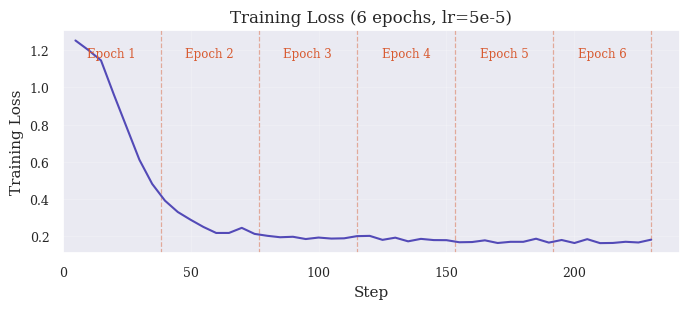

In [18]:
# @title
# @no-extract
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

logs = trainer.state.log_history

steps  = [l["step"] for l in logs if "loss" in l]
losses = [l["loss"] for l in logs if "loss" in l]

NUM_EPOCHS = 6
# Fix: use the actual final step number, not the count of log entries
steps_per_epoch = steps[-1] / NUM_EPOCHS

plt.rcParams.update({
    "font.family":    "serif",
    "font.size":      10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, ax = plt.subplots(figsize=(7, 3.2))

ax.plot(steps, losses, color='#534AB7', linewidth=1.5, zorder=3)

y_label = max(losses) * 0.97   # near top, inside axes

for epoch in range(1, NUM_EPOCHS + 1):
    boundary = epoch * steps_per_epoch
    ax.axvline(x=boundary, color='#D85A30', linestyle='--',
               alpha=0.45, linewidth=0.9, zorder=2)
    # Place label at mid-span so labels never overlap each other
    mid = boundary - steps_per_epoch * 0.5
    ax.text(mid, y_label, f'Epoch {epoch}',
            ha='center', va='top', fontsize=8.5, color='#D85A30')

ax.set_xlabel('Step')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss (6 epochs, lr=5e-5)')
ax.grid(True, which='major', alpha=0.25, linewidth=0.6)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig('/content/finetune_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
# @title
# Save the trained adapter
model.save_pretrained("/content/trained_adapter")
tokenizer.save_pretrained("/content/trained_adapter")

print("Adapter saved")

Unsloth: Restored added_tokens_decoder metadata in /content/trained_adapter/tokenizer_config.json.


Adapter saved


In [20]:
# @title
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="/content/trained_adapter",
    max_seq_length=2048,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("Model reloaded for inference")

==((====))==  Unsloth 2026.5.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model reloaded for inference


In [21]:
# @title
import torch
import json
from datetime import datetime
from tqdm import tqdm

results = []

for i in tqdm(range(len(test_dataset))):
    sample = test_dataset[i]

    messages = [
        {"role": "system", "content": sample["messages"][0]["content"]},
        {"role": "user", "content": sample["messages"][1]["content"]},
    ]

    input_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    input_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=1024,
            temperature=0.1,
            do_sample=True,
            use_cache=False,
        )

    generated = tokenizer.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True
    )

    results.append({
        "sample_id": sample["sample_id"],
        "domain_id": sample["domain_id"],
        "input": sample["messages"][1]["content"],
        "expected": sample["messages"][2]["content"],
        "predicted": generated,
    })

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f"/content/finetune_eval_{timestamp}.jsonl"
with open(output_path, "w") as f:
    for r in results:
        f.write(json.dumps(r) + "\n")

print(f"Saved {len(results)} results to {output_path}")

  0%|          | 0/78 [00:00<?, ?it/s]Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, F

Saved 78 results to /content/finetune_eval_20260527_071224.jsonl


In [22]:
# @title
max_output = max(len(tokenizer.encode(s["messages"][2]["content"])) for s in test_dataset)
print(f"Longest expected output: {max_output} tokens")

Longest expected output: 715 tokens


In [23]:
# @title
# @no-extract
# check any test sample is larger than max token size 2048
for s in test_dataset:
    input_text = tokenizer.apply_chat_template(
        [s["messages"][0], s["messages"][1]],
        tokenize=False,
        add_generation_prompt=True
    )
    input_len = len(tokenizer.encode(input_text))
    output_len = len(tokenizer.encode(s["messages"][2]["content"]))
    total = input_len + output_len
    if total > 2048:
        print(f"WARNING {s['sample_id']}: input={input_len} + output={output_len} = {total}")

print("Done")

Done


In [24]:
# @title
# @no-extract
import json

with open(output_path) as f:
    results = [json.loads(line) for line in f]

correct_name = 0
wrong_name = 0
correct_detected = 0
wrong_detected = 0
invalid_json = 0

target_name = "Functional Decomposition: Using the include relationship"

for r in results:
    try:
        expected = json.loads(r["expected"])
        predicted = json.loads(r["predicted"])
    except json.JSONDecodeError:
        invalid_json += 1
        continue

    # Detection accuracy
    if expected["detected"] == predicted["detected"]:
        correct_detected += 1
    else:
        wrong_detected += 1

    # Name accuracy (only for true positives)
    if expected["detected"] and predicted["detected"]:
        pred_names = [a["antipattern_name"] for a in predicted.get("antipatterns", [])]
        if target_name in pred_names:
            correct_name += 1
        else:
            wrong_name += 1
            print(f"  Wrong name in {r['sample_id']}: {pred_names}")

print(f"\n=== Results ===")
print(f"Total: {len(results)}")
print(f"Invalid JSON: {invalid_json}")
print(f"Detection correct: {correct_detected}/{correct_detected + wrong_detected}")
print(f"Name correct: {correct_name}/{correct_name + wrong_name}")


=== Results ===
Total: 78
Invalid JSON: 0
Detection correct: 71/78
Name correct: 39/39
